# Task 5: Time-Series Forecasting with ARIMA

## Objective
Build an end-to-end time-series forecasting pipeline by analyzing historical trends, seasonality, stationarity, and generating future demand predictions.

### Methods Used
- Time-Series Decomposition
- Augmented Dickey-Fuller (ADF) Test
- Differencing
- ARIMA Forecasting
- MAPE and RMSE Evaluation
- 30-Day Future Forecast

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [8]:
df = pd.read_csv("../data/daily-demand-series.csv")

df.head()

,date,demand,marketing_event,holiday
0,01-06-2026,118,0,0
1,02-06-2026,121,0,0
2,03-06-2026,125,0,0
3,04-06-2026,123,0,0
4,05-06-2026,137,1,0


In [10]:
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")
df = df.sort_values("date")
df = df.set_index("date")

df.head()

,demand,marketing_event,holiday
date,,,
2026-06-01,118,0,0
2026-06-02,121,0,0
2026-06-03,125,0,0
2026-06-04,123,0,0
2026-06-05,137,1,0


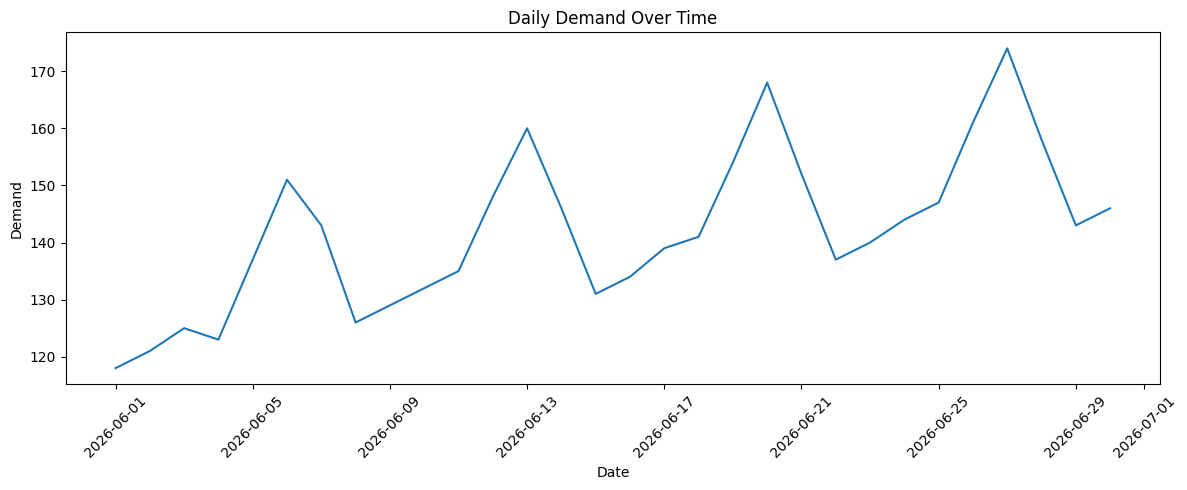

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["demand"])
plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

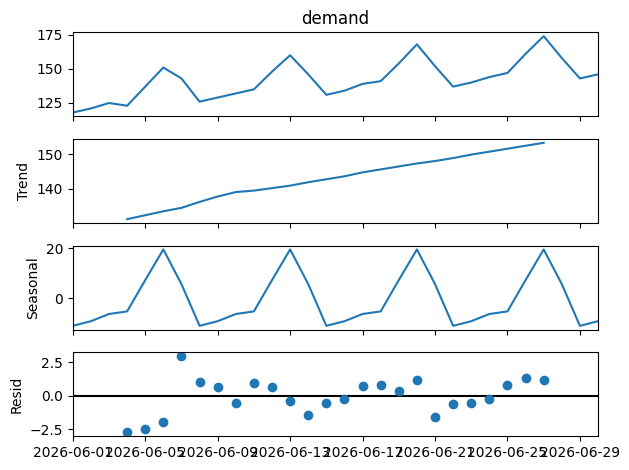

In [12]:
decomposition = seasonal_decompose(
    df["demand"],
    model="additive",
    period=7
)

decomposition.plot()
plt.tight_layout()
plt.show()

In [13]:
adf_result = adfuller(df["demand"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is not stationary.")

ADF Statistic: -0.9038698873856347
p-value: 0.7866953368372339
The series is not stationary.


In [14]:
df["demand_diff"] = df["demand"].diff()

df["demand_diff"].dropna().head()

date
2026-06-02     3.0
2026-06-03     4.0
2026-06-04    -2.0
2026-06-05    14.0
2026-06-06    14.0
Name: demand_diff, dtype: float64

In [15]:
adf_diff = adfuller(df["demand_diff"].dropna())

print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

if adf_diff[1] < 0.05:
    print("The differenced series is stationary.")
else:
    print("The differenced series is not stationary.")

ADF Statistic: -2.2336240127354112
p-value: 0.19426893706635717
The differenced series is not stationary.


In [16]:
train = df["demand"].iloc[:-7]
test = df["demand"].iloc[-7:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 23
Testing observations: 7


In [17]:
import itertools

p_values = [0, 1, 2]
d_values = [0, 1, 2]
q_values = [0, 1, 2]

best_aic = float("inf")
best_order = None

for order in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(train, order=order)
        fitted_model = model.fit()

        if fitted_model.aic < best_aic:
            best_aic = fitted_model.aic
            best_order = order

    except:
        continue

print("Best ARIMA order:", best_order)
print("Best AIC:", best_aic)

Best ARIMA order: (2, 2, 2)
Best AIC: 160.10669126333508


In [18]:
model = ARIMA(train, order=(2, 2, 2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

print("Forecasted values:")
print(forecast)

Forecasted values:
2026-06-24    146.220591
2026-06-25    146.595708
2026-06-26    144.996260
2026-06-27    146.082604
2026-06-28    148.315470
2026-06-29    149.331385
2026-06-30    149.706023
Freq: D, Name: predicted_mean, dtype: float64


In [19]:
mape = np.mean(
    np.abs((test.values - forecast.values) / test.values)
) * 100

rmse = np.sqrt(
    mean_squared_error(test, forecast)
)

print("MAPE:", mape, "%")
print("RMSE:", rmse)


MAPE: 5.842451578470975 %
RMSE: 13.02857485724692


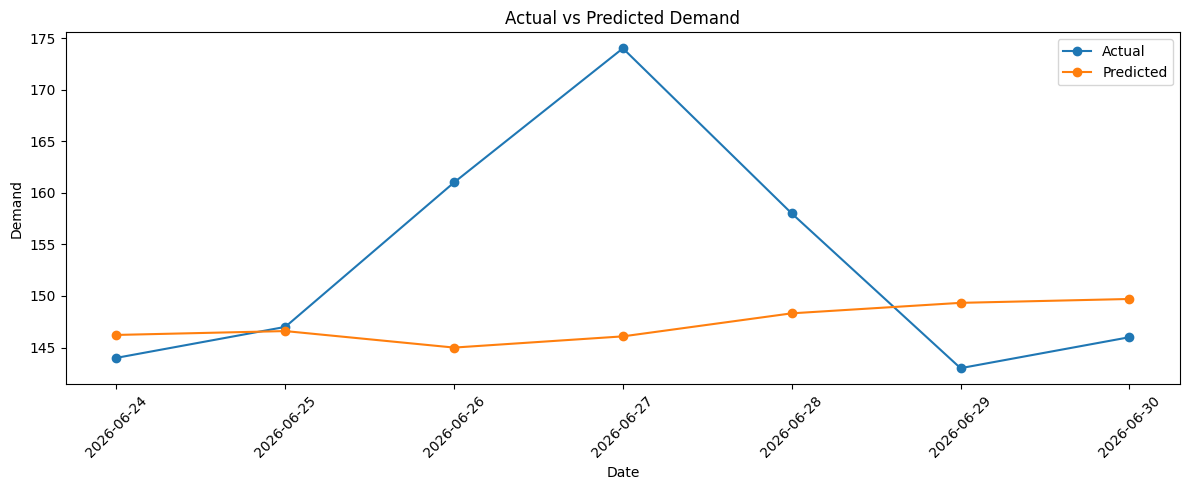

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(test.index, test.values, marker="o", label="Actual")
plt.plot(test.index, forecast.values, marker="o", label="Predicted")

plt.title("Actual vs Predicted Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
final_model = ARIMA(df["demand"], order=(2, 2, 2))
final_model_fit = final_model.fit()

print("Final ARIMA model fitted successfully.")

Final ARIMA model fitted successfully.


In [22]:
future_forecast = final_model_fit.forecast(steps=30)

print("30-Day Forecast:")
print(future_forecast)

30-Day Forecast:
2026-07-01    152.034088
2026-07-02    152.284636
2026-07-03    150.685839
2026-07-04    151.784372
2026-07-05    153.956885
2026-07-06    154.885015
2026-07-07    155.210158
2026-07-08    156.102468
2026-07-09    157.324870
2026-07-10    158.292322
2026-07-11    159.082643
2026-07-12    159.985719
2026-07-13    160.982299
2026-07-14    161.929986
2026-07-15    162.828998
2026-07-16    163.748688
2026-07-17    164.693410
2026-07-18    165.629673
2026-07-19    166.553202
2026-07-20    167.480032
2026-07-21    168.413275
2026-07-22    169.345322
2026-07-23    170.274170
2026-07-24    171.203395
2026-07-25    172.134201
2026-07-26    173.064926
2026-07-27    173.994876
2026-07-28    174.924815
2026-07-29    175.855131
2026-07-30    176.785476
Freq: D, Name: predicted_mean, dtype: float64


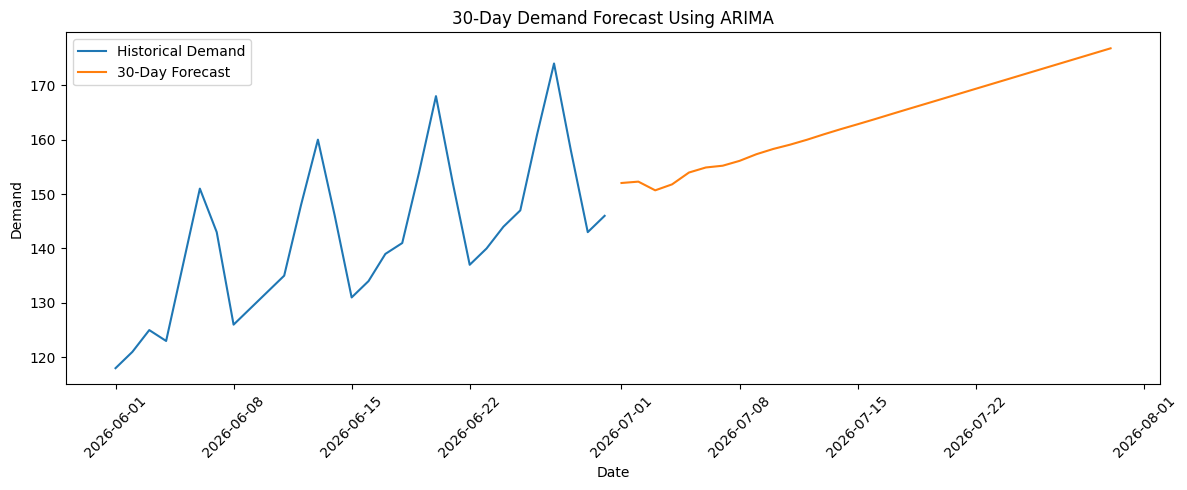

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(df.index, df["demand"], label="Historical Demand")
plt.plot(future_forecast.index, future_forecast.values, label="30-Day Forecast")

plt.title("30-Day Demand Forecast Using ARIMA")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Results and Interpretation

## Time-Series Analysis
The daily demand data was analyzed to identify its historical trend and weekly seasonal pattern. Time-series decomposition separated the data into observed, trend, seasonal, and residual components.

## Stationarity Analysis
The Augmented Dickey-Fuller (ADF) test was performed on the original demand series.

- ADF p-value: 0.786695
- Result: The original demand series was not stationary.

First-order differencing was then applied and the ADF test was repeated.

- Differenced-series ADF p-value: 0.194268
- Result: The differenced series did not pass the 5% stationarity threshold.

ARIMA model selection was therefore performed using AIC across multiple combinations of p, d, and q parameters.

## ARIMA Model
The best-performing model according to AIC was:

*ARIMA(2, 2, 2)*

Best AIC: *160.1067*

## Forecast Accuracy
The model was evaluated using the final 7 observations as the test set.

- *MAPE: 5.84%*
- *RMSE: 13.03*

The MAPE indicates that the forecast errors were relatively small on average for the test period.

## 30-Day Forecast
The final ARIMA(2, 2, 2) model was fitted using the complete available demand series and used to generate a 30-day future forecast.

The forecast covers:

*July 1, 2026 to July 30, 2026*

The predicted demand shows an overall increasing trend during the forecast period.

## Conclusion
The time-series forecasting pipeline successfully analyzed historical demand, examined stationarity, applied differencing, selected an ARIMA model using AIC, evaluated forecast accuracy using MAPE and RMSE, and generated a 30-day future demand forecast.